# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [21]:
# ===============================
# 1️⃣ Carregue a base e ajuste tipos de dados
# ===============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno  # para visualizar nulos

In [22]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [23]:
# Ajustando tipos de dados
df['Pagamento_Mensal'] = pd.to_numeric(df['Pagamento_Mensal'], errors='coerce')
df['Total_Pago'] = pd.to_numeric(df['Total_Pago'], errors='coerce')
df['Idoso'] = df['Idoso'].astype('int64')

print("Informações gerais após ajustes:")
print(df.info())

Informações gerais após ajustes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               24

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

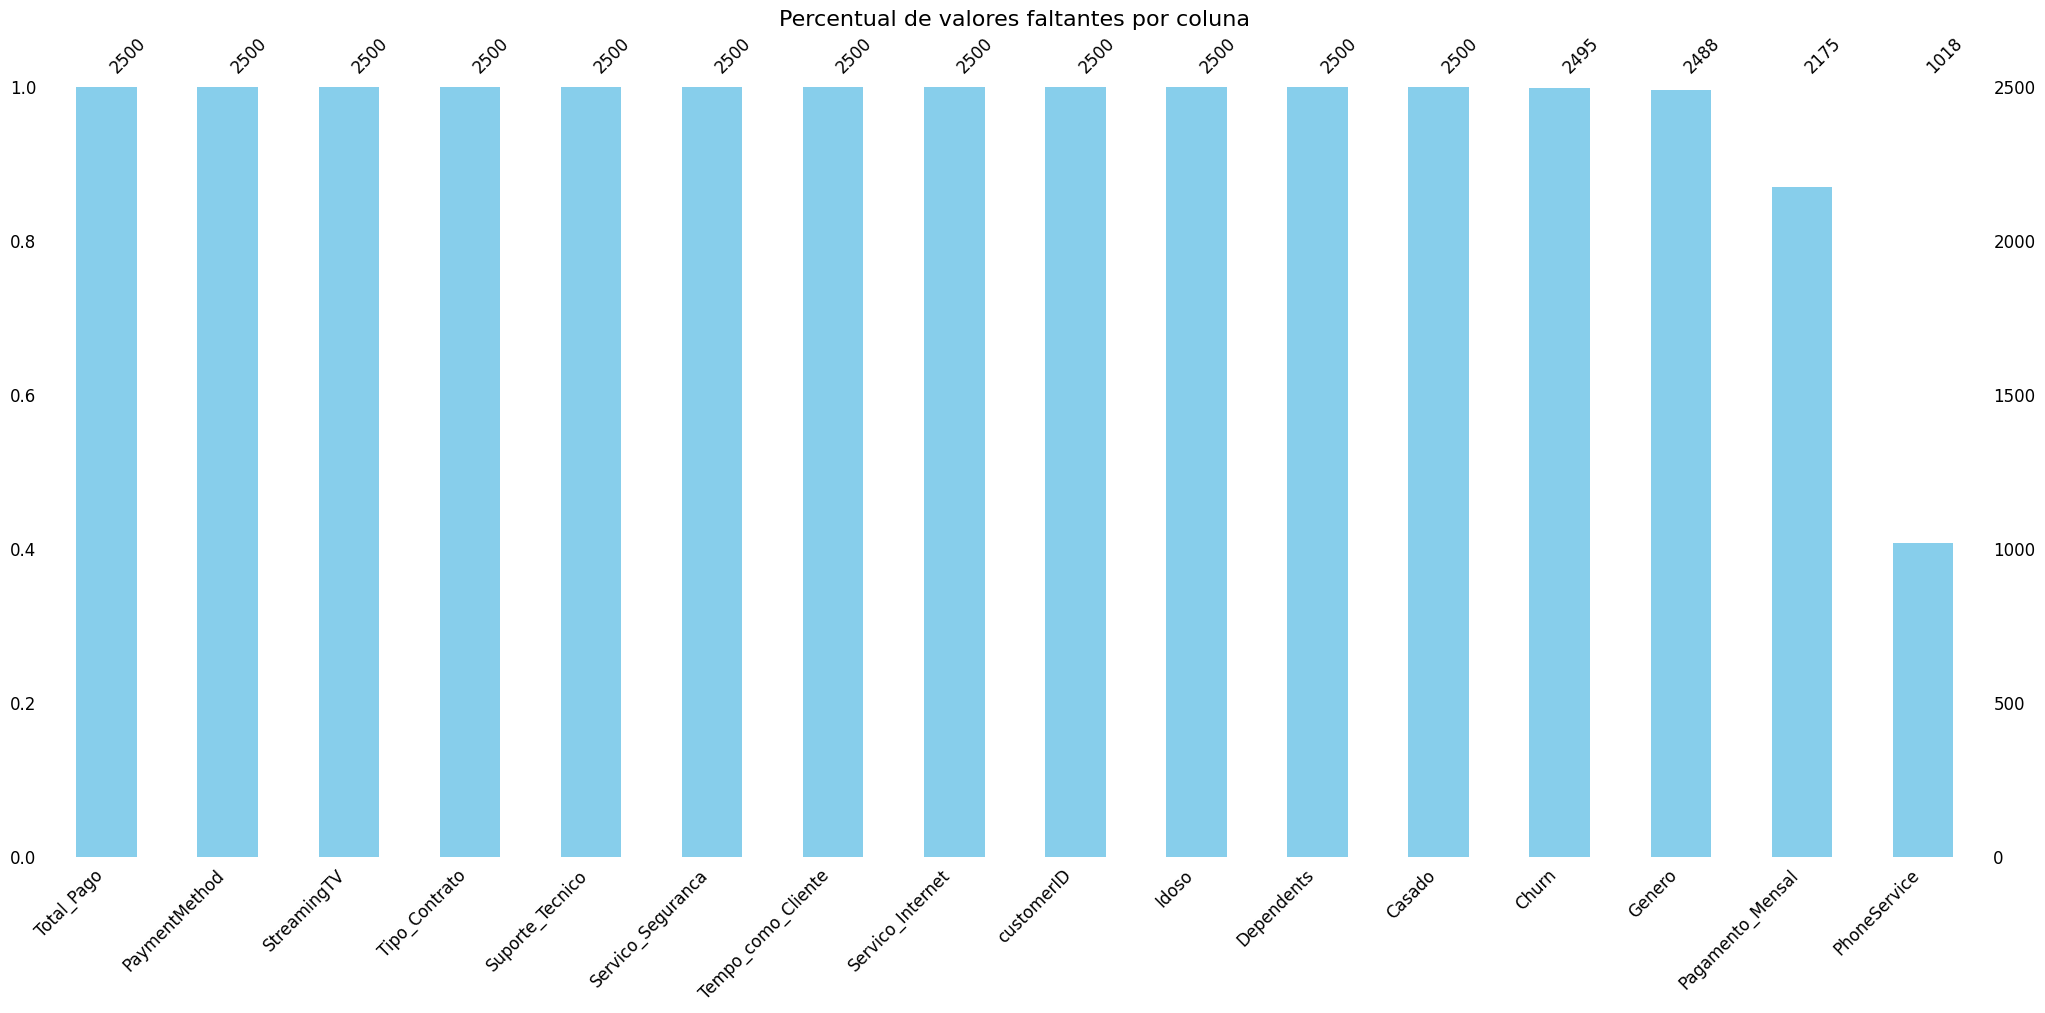

<Figure size 1200x600 with 0 Axes>

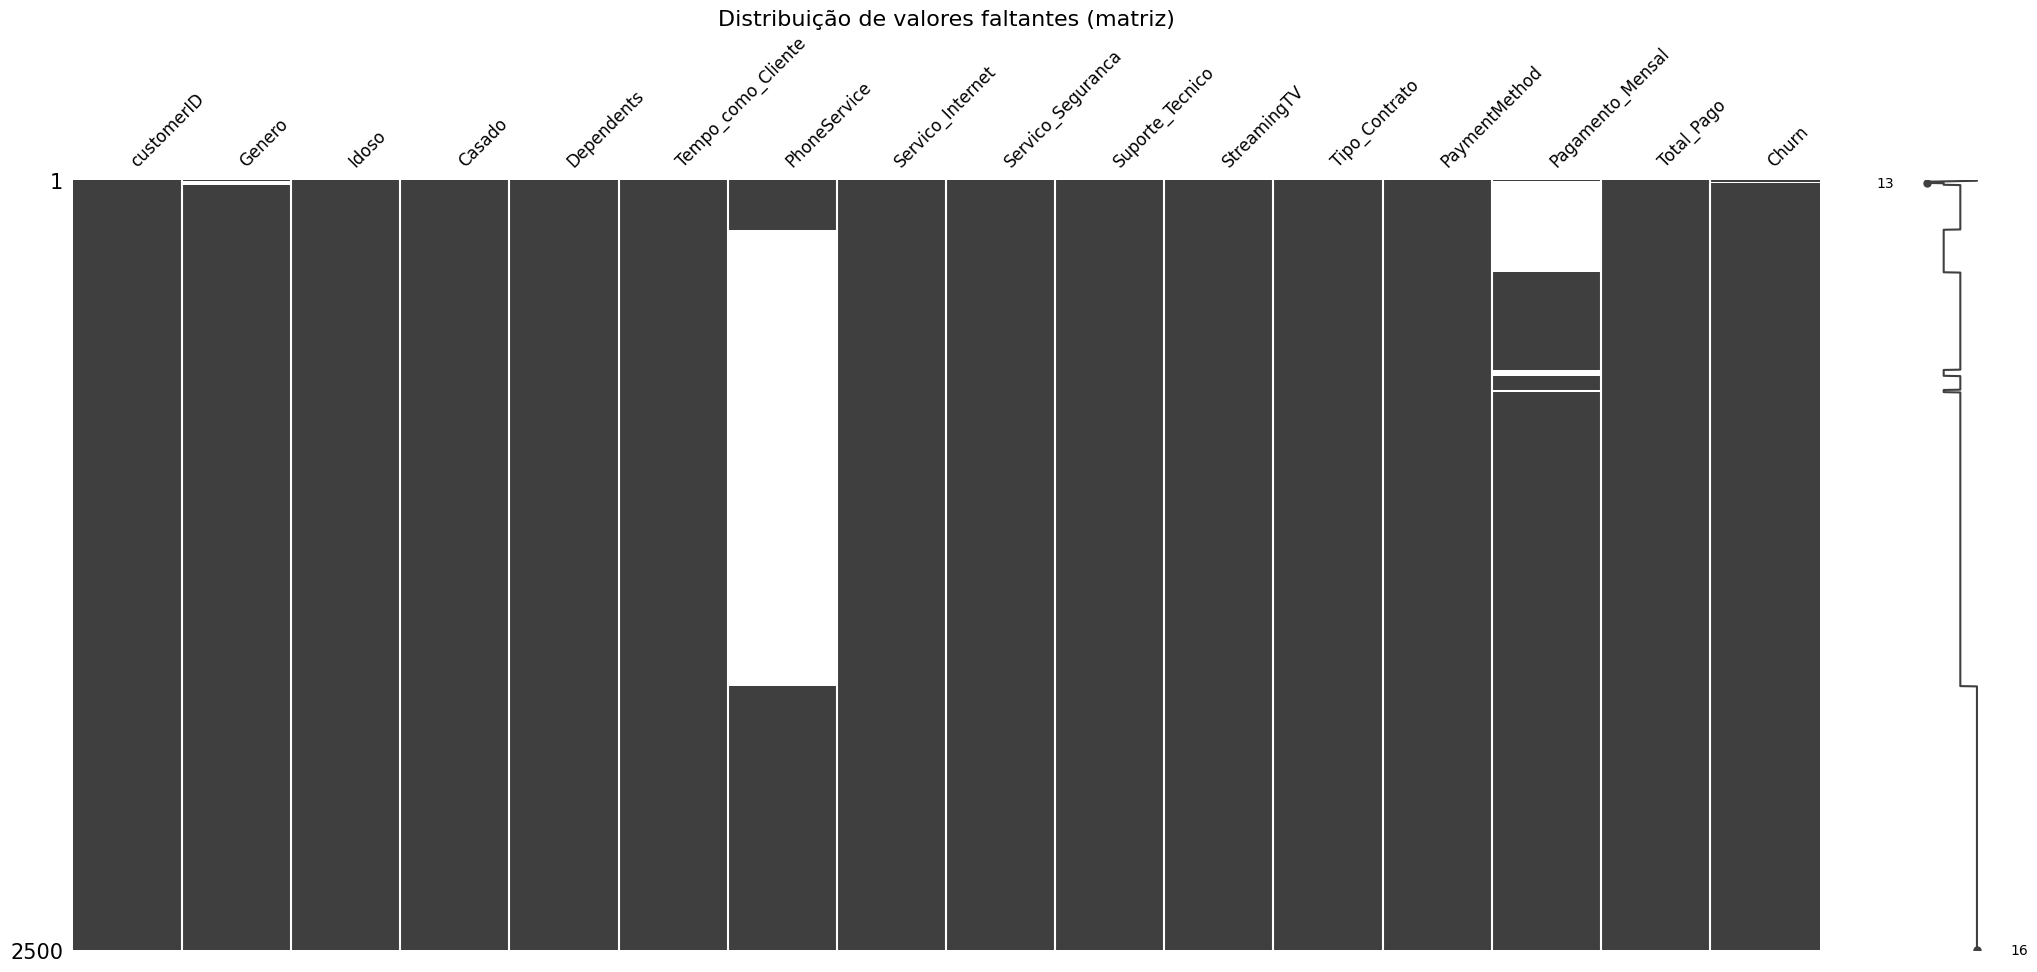

<Figure size 1000x800 with 0 Axes>

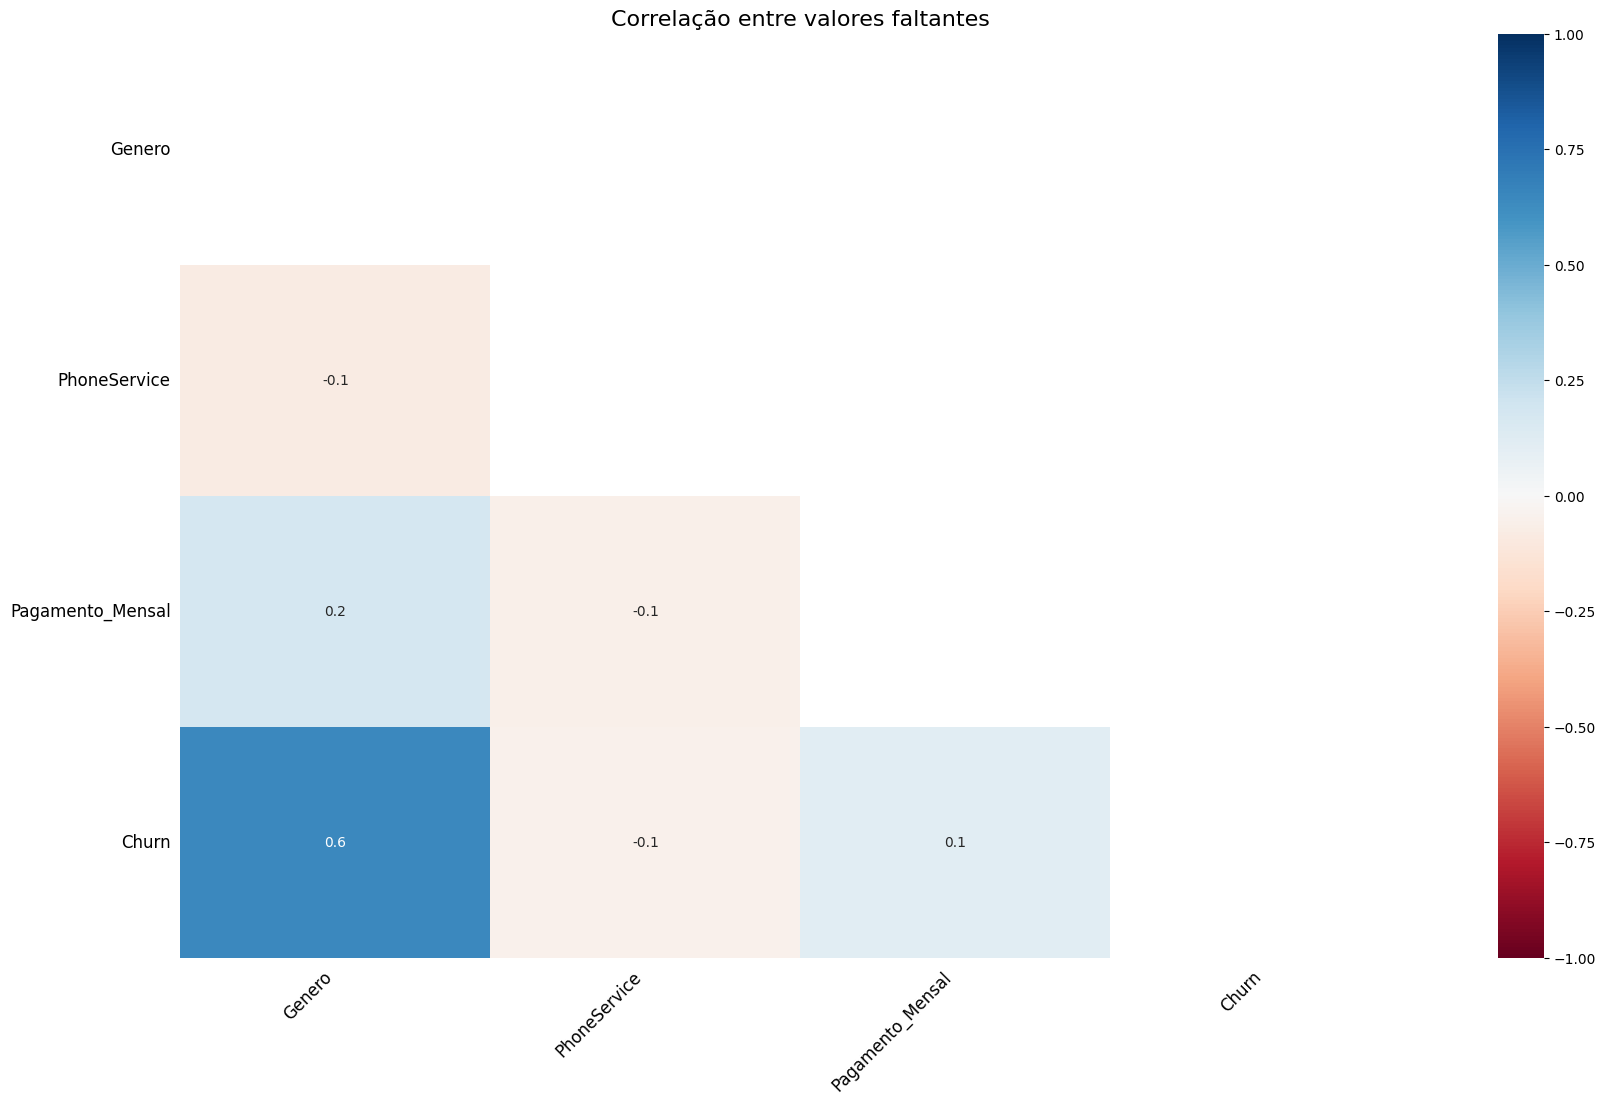

In [24]:
# -------------------------------
# Checando valores faltantes
# -------------------------------
# 2A - Visualização dos valores faltantes
plt.figure(figsize=(12,6))
msno.bar(df, fontsize=12, color='skyblue', sort='descending')
plt.title("Percentual de valores faltantes por coluna", fontsize=16)
plt.show()

plt.figure(figsize=(12,6))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Distribuição de valores faltantes (matriz)", fontsize=16)
plt.show()

plt.figure(figsize=(10,8))
msno.heatmap(df, fontsize=12)
plt.title("Correlação entre valores faltantes", fontsize=16)
plt.show()

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [25]:
# 2B - Substituição (imputação) de valores faltantes
# Justificativa:
# - Variáveis categóricas (como 'Genero' e 'Churn'): substituídas pela moda (valor mais frequente)
# - Variáveis numéricas (como 'Pagamento_Mensal'): substituídas pela mediana (robusta a outliers)

# Substituição em variáveis categóricas
df['Genero'].fillna(df['Genero'].mode()[0], inplace=True)
df['Churn'].fillna(df['Churn'].mode()[0], inplace=True)

# Substituição em variáveis numéricas
df['Pagamento_Mensal'].fillna(df['Pagamento_Mensal'].median(), inplace=True)
df['Total_Pago'].fillna(df['Total_Pago'].median(), inplace=True)

# Caso exista alguma coluna categórica com valores ausentes adicionais:
df.fillna(df.mode().iloc[0], inplace=True)

print("Valores faltantes após imputação:")
print(df.isnull().sum())

Valores faltantes após imputação:
customerID            0
Genero                0
Idoso                 0
Casado                0
Dependents            0
Tempo_como_Cliente    0
PhoneService          0
Servico_Internet      0
Servico_Seguranca     0
Suporte_Tecnico       0
StreamingTV           0
Tipo_Contrato         0
PaymentMethod         0
Pagamento_Mensal      0
Total_Pago            0
Churn                 0
dtype: int64


C:\Users\msn_j.000\AppData\Local\Temp\ipykernel_11964\1497023905.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Genero'].fillna(df['Genero'].mode()[0], inplace=True)
C:\Users\msn_j.000\AppData\Local\Temp\ipykernel_11964\1497023905.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

Média de Pagamento_Mensal: 66.36708
Mediana de Pagamento_Mensal: 71.45


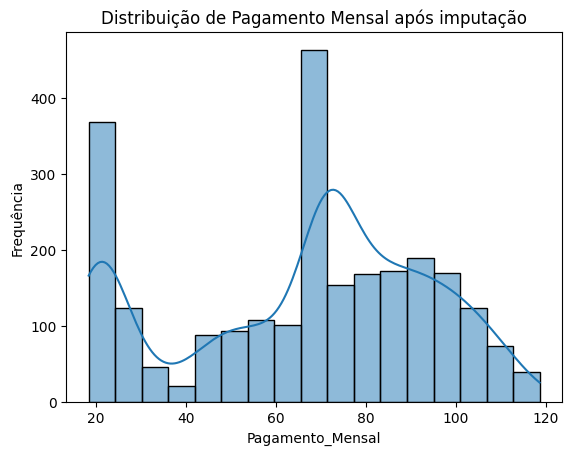

Servico_Internet
Fiber optic    1127
DSL             836
No              528
dsl               9
Name: count, dtype: int64


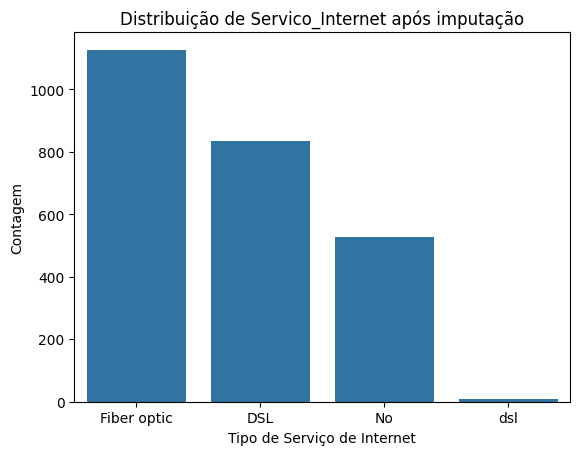

In [26]:
# -------------------------------
# 2C - Verificação da distribuição (após imputação)
# -------------------------------
print("Média de Pagamento_Mensal:", df['Pagamento_Mensal'].mean())
print("Mediana de Pagamento_Mensal:", df['Pagamento_Mensal'].median())

sns.histplot(df['Pagamento_Mensal'], kde=True)
plt.title("Distribuição de Pagamento Mensal após imputação")
plt.xlabel("Pagamento_Mensal")
plt.ylabel("Frequência")
plt.show()

print(df['Servico_Internet'].value_counts())
sns.countplot(x=df['Servico_Internet'], order=df['Servico_Internet'].value_counts().index)
plt.title("Distribuição de Servico_Internet após imputação")
plt.xlabel("Tipo de Serviço de Internet")
plt.ylabel("Contagem")
plt.show()

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [27]:
# ===============================
# 3️⃣ Padronização de valores inconsistentes
# ===============================
df['Servico_Internet'] = df['Servico_Internet'].astype(str).str.strip().str.lower()

df['Servico_Internet'] = df['Servico_Internet'].replace({
    'dsl': 'DSL',
    'fiber optic': 'Fiber Optic',
    'no': 'No'
})

# Padronizando todas as colunas categóricas para formato Title Case
cols_cat = df.select_dtypes(include='object').columns
for col in cols_cat:
    df[col] = df[col].astype(str).str.strip().str.title()

# Padronizando 'No Internet Service' de forma mais Pythonic
colunas_padronizar = ['Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV']
df[colunas_padronizar] = df[colunas_padronizar].replace('No Internet Service', 'No')



# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [28]:
# ===============================
# 4️⃣ Renomeação de colunas (para manter padrão em português)
# ===============================
df = df.rename(columns={
    'customerID': 'Cliente_ID',
    'Genero': 'Genero',
    'Idoso': 'Eh_Idoso',
    'Casado': 'Eh_Casado',
    'Dependents': 'Tem_Dependentes',
    'Tempo_como_Cliente': 'Meses_Como_Cliente',
    'PhoneService': 'Servico_Telefone',
    'Servico_Internet': 'Tipo_Internet',
    'Servico_Seguranca': 'Servico_Seguranca',
    'Suporte_Tecnico': 'Suporte_Tecnico',
    'StreamingTV': 'Servico_Streaming',
    'Tipo_Contrato': 'Tipo_Contrato',
    'PaymentMethod': 'Metodo_Pagamento',
    'Pagamento_Mensal': 'Valor_Mensal',
    'Total_Pago': 'Total_Pago',
    'Churn': 'Churn'
})


In [29]:
print("Valores nulos após todas as transformações:")
print(df.isnull().sum())

print("\nInformações finais do DataFrame:")
print(df.info())

print("\nPrévia dos dados:")
print(df.head())

print("\nResumo estatístico:")
print(df.describe(include='all'))


Valores nulos após todas as transformações:
Cliente_ID            0
Genero                0
Eh_Idoso              0
Eh_Casado             0
Tem_Dependentes       0
Meses_Como_Cliente    0
Servico_Telefone      0
Tipo_Internet         0
Servico_Seguranca     0
Suporte_Tecnico       0
Servico_Streaming     0
Tipo_Contrato         0
Metodo_Pagamento      0
Valor_Mensal          0
Total_Pago            0
Churn                 0
dtype: int64

Informações finais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cliente_ID          2500 non-null   object 
 1   Genero              2500 non-null   object 
 2   Eh_Idoso            2500 non-null   int64  
 3   Eh_Casado           2500 non-null   object 
 4   Tem_Dependentes     2500 non-null   object 
 5   Meses_Como_Cliente  2500 non-null   int64  
 6   Servico_Telefone    2